In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# Armazenar em uma variavel
df = pd.read_csv(r".\data\dataset_techshop_vendas.csv")
df.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   data_pedido      800 non-null    str    
 1   categoria        800 non-null    str    
 2   preco_unitario   800 non-null    float64
 3   quantidade       800 non-null    int64  
 4   regiao           800 non-null    str    
 5   canal_marketing  800 non-null    str    
 6   avaliacao        800 non-null    float64
dtypes: float64(2), int64(1), str(4)
memory usage: 70.9 KB


In [4]:
# Armazenar em uma variavel
df = pd.read_csv(r".\data\dataset_techshop_vendas.csv",parse_dates=["data_pedido"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data_pedido      800 non-null    datetime64[us]
 1   categoria        800 non-null    str           
 2   preco_unitario   800 non-null    float64       
 3   quantidade       800 non-null    int64         
 4   regiao           800 non-null    str           
 5   canal_marketing  800 non-null    str           
 6   avaliacao        800 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 63.1 KB


In [5]:
df["faturamento"] = df["preco_unitario"] * df["quantidade"]
df.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3,36.20
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4,613.05
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6,604.76
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1,6798.32
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9,6361.88


In [6]:
faturamento_total = df["faturamento"].sum()
print(faturamento_total)

2847624.13


In [7]:
faturamento_formatado = f"{faturamento_total:,.2f}".replace(",","x").replace(",",",").replace("x",".")
print(f"O faturamento total foi de R${faturamento_formatado}")

O faturamento total foi de R$2.847.624.13


In [8]:
df.loc["total"] = df.sum(numeric_only=True)
df.tail()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
796,2024-12-27 00:00:00,Acessórios,209.29,4.0,Sudeste,Google Ads,3.8,837.16
797,2024-12-28 00:00:00,Notebooks,7979.84,2.0,Sudeste,Google Ads,4.4,15959.68
798,2024-12-28 00:00:00,Notebooks,4168.01,1.0,Nordeste,Instagram,4.1,4168.01
799,2024-12-28 00:00:00,Acessórios,111.95,1.0,Sul,Google Ads,4.7,111.95
total,NaN,NaN,1739011.23,1790.0,NaN,NaN,3332.4,2847624.13


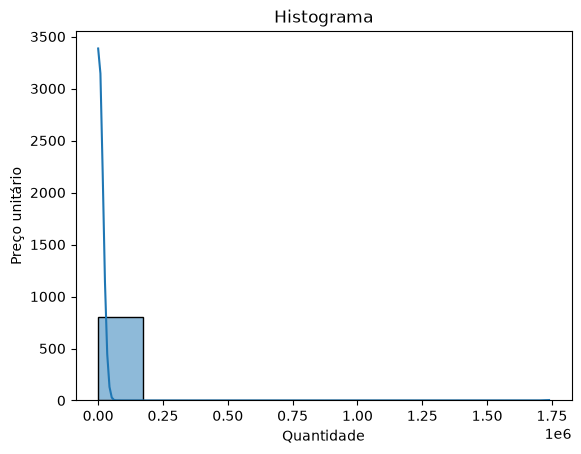

In [9]:
grafico = sns.histplot(data=df,x="preco_unitario",bins=10,kde=True);
grafico.set_title("Histograma");
grafico.set_ylabel("Preço unitário");
grafico.set_xlabel("Quantidade");
